<a href="https://colab.research.google.com/github/xwang335/Campbell-A/blob/main/GLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import torch
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple


In [2]:
# ============================================================
# 0. basic config
# ============================================================
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
# ============================================================
# 1. spline basis
# ============================================================

@dataclass
class SplineSpec:
    feature_names: List[str]
    n_knots: int = 3
    include_linear: bool = True
    quantile_low: float = 0.05
    quantile_high: float = 0.95


def compute_knots_from_train(
    x_train: np.ndarray,
    n_knots: int,
    q_low: float = 0.05,
    q_high: float = 0.95,
) -> np.ndarray:
    """
    Compute knot locations from TRAINING data only.
    """
    if n_knots <= 0:
        return np.array([], dtype=float)

    qs = np.linspace(q_low, q_high, n_knots + 2)[1:-1]
    knots = np.quantile(x_train[~np.isnan(x_train)], qs)
    return np.asarray(knots, dtype=float)


def truncated_quadratic_basis(
    x: np.ndarray,
    knots: np.ndarray,
    include_linear: bool = True,
) -> np.ndarray:
    """
    Basis for one feature:
        [x, (x-c1)_+^2, ..., (x-cm)_+^2]
    or only hinge terms if include_linear=False
    """
    cols = []

    if include_linear:
        cols.append(x.reshape(-1, 1))

    for c in knots:
        cols.append(np.maximum(x - c, 0.0).reshape(-1, 1) ** 2)

    if len(cols) == 0:
        raise ValueError("Basis is empty. Need include_linear=True or n_knots>0.")

    return np.concatenate(cols, axis=1)



In [4]:

# ============================================================
# 2. build GLM design matrix + group structure
# ============================================================

@dataclass
class GLMDesign:
    X: torch.Tensor               # no intercept inside; intercept handled separately
    y: torch.Tensor
    group_slices: List[slice]     # one slice per raw feature
    knot_dict: Dict[str, np.ndarray]
    scaler_mean: Dict[str, float]
    scaler_std: Dict[str, float]
    feature_names: List[str]


def fit_feature_scaler(x_train: np.ndarray) -> Tuple[float, float]:
    mu = np.nanmean(x_train)
    sd = np.nanstd(x_train)
    if not np.isfinite(sd) or sd < 1e-12:
        sd = 1.0
    return float(mu), float(sd)


def apply_feature_scaler(x: np.ndarray, mu: float, sd: float) -> np.ndarray:
    return (x - mu) / sd


def build_glm_design_train(
    df_train: pd.DataFrame,
    y_col: str,
    spec: SplineSpec,
    device: Optional[torch.device] = None,
) -> GLMDesign:
    """
    Fit scaling + knots using training sample only, and build training design matrix.
    """
    if device is None:
        device = get_device()

    X_blocks = []
    group_slices = []
    knot_dict = {}
    scaler_mean = {}
    scaler_std = {}

    col_start = 0

    for feat in spec.feature_names:
        x_raw = df_train[feat].to_numpy(dtype=float)

        mu, sd = fit_feature_scaler(x_raw)
        x_std = apply_feature_scaler(x_raw, mu, sd)

        knots = compute_knots_from_train(
            x_train=x_std,
            n_knots=spec.n_knots,
            q_low=spec.quantile_low,
            q_high=spec.quantile_high,
        )

        block = truncated_quadratic_basis(
            x=x_std,
            knots=knots,
            include_linear=spec.include_linear,
        )

        k = block.shape[1]
        group_slices.append(slice(col_start, col_start + k))
        col_start += k

        X_blocks.append(block)
        knot_dict[feat] = knots
        scaler_mean[feat] = mu
        scaler_std[feat] = sd

    X_np = np.concatenate(X_blocks, axis=1)
    y_np = df_train[y_col].to_numpy(dtype=float).reshape(-1)

    # optional: drop rows with nan in y or X
    valid = np.isfinite(y_np) & np.all(np.isfinite(X_np), axis=1)
    X_np = X_np[valid]
    y_np = y_np[valid]

    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    y = torch.tensor(y_np, dtype=torch.float32, device=device)

    return GLMDesign(
        X=X,
        y=y,
        group_slices=group_slices,
        knot_dict=knot_dict,
        scaler_mean=scaler_mean,
        scaler_std=scaler_std,
        feature_names=spec.feature_names,
    )


def build_glm_design_apply(
    df: pd.DataFrame,
    y_col: str,
    fitted_design: GLMDesign,
    spec: SplineSpec,
    device: Optional[torch.device] = None,
) -> GLMDesign:
    """
    Use training-fitted scaler + knots to build validation/test design matrix.
    """
    if device is None:
        device = get_device()

    X_blocks = []

    for feat in spec.feature_names:
        x_raw = df[feat].to_numpy(dtype=float)

        mu = fitted_design.scaler_mean[feat]
        sd = fitted_design.scaler_std[feat]
        knots = fitted_design.knot_dict[feat]

        x_std = apply_feature_scaler(x_raw, mu, sd)

        block = truncated_quadratic_basis(
            x=x_std,
            knots=knots,
            include_linear=spec.include_linear,
        )
        X_blocks.append(block)

    X_np = np.concatenate(X_blocks, axis=1)
    y_np = df[y_col].to_numpy(dtype=float).reshape(-1)

    valid = np.isfinite(y_np) & np.all(np.isfinite(X_np), axis=1)
    X_np = X_np[valid]
    y_np = y_np[valid]

    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    y = torch.tensor(y_np, dtype=torch.float32, device=device)

    return GLMDesign(
        X=X,
        y=y,
        group_slices=fitted_design.group_slices,
        knot_dict=fitted_design.knot_dict,
        scaler_mean=fitted_design.scaler_mean,
        scaler_std=fitted_design.scaler_std,
        feature_names=fitted_design.feature_names,
    )



In [5]:

# ============================================================
# 3. loss and gradient
# ============================================================

def predict_glm(X: torch.Tensor, beta: torch.Tensor, intercept: torch.Tensor) -> torch.Tensor:
    return intercept + X @ beta


def l2_loss_and_grad(
    X: torch.Tensor,
    y: torch.Tensor,
    beta: torch.Tensor,
    intercept: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Returns:
        loss, grad_beta, grad_intercept
    loss = mean((y - yhat)^2)
    """
    yhat = predict_glm(X, beta, intercept)
    resid = y - yhat
    n = y.shape[0]

    loss = torch.mean(resid ** 2)

    grad_beta = -(2.0 / n) * (X.T @ resid)
    grad_intercept = -(2.0 / n) * torch.sum(resid)

    return loss, grad_beta, grad_intercept


def huber_loss_and_grad(
    X: torch.Tensor,
    y: torch.Tensor,
    beta: torch.Tensor,
    intercept: torch.Tensor,
    xi: float,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Huber loss:
        x^2                     if |x| <= xi
        2*xi*|x| - xi^2         if |x| > xi
    """
    yhat = predict_glm(X, beta, intercept)
    resid = y - yhat
    abs_r = torch.abs(resid)
    n = y.shape[0]

    quad_mask = abs_r <= xi
    loss_vec = torch.where(
        quad_mask,
        resid ** 2,
        2.0 * xi * abs_r - xi ** 2
    )
    loss = torch.mean(loss_vec)

    psi = torch.where(
        quad_mask,
        2.0 * resid,
        2.0 * xi * torch.sign(resid)
    )

    grad_beta = -(1.0 / n) * (X.T @ psi)
    grad_intercept = -(1.0 / n) * torch.sum(psi)

    return loss, grad_beta, grad_intercept



In [6]:

# ============================================================
# 4. group lasso prox
# ============================================================

def prox_group_lasso(
    v: torch.Tensor,
    step_size: float,
    lam: float,
    group_slices: List[slice],
) -> torch.Tensor:
    """
    Group lasso prox:
        prox(v_g) = (1 - step*lam / ||v_g||)_+ * v_g
    """
    out = v.clone()

    for g in group_slices:
        block = out[g]
        norm = torch.norm(block, p=2)

        thresh = step_size * lam
        if norm <= thresh:
            out[g] = 0.0
        else:
            shrink = 1.0 - thresh / norm
            out[g] = shrink * block

    return out



In [7]:
# ============================================================
# 5. objective
# ============================================================

def group_lasso_penalty(beta: torch.Tensor, lam: float, group_slices: List[slice]) -> torch.Tensor:
    pen = torch.zeros(1, dtype=beta.dtype, device=beta.device)
    for g in group_slices:
        pen = pen + lam * torch.norm(beta[g], p=2)
    return pen.squeeze()


def objective_value(
    X: torch.Tensor,
    y: torch.Tensor,
    beta: torch.Tensor,
    intercept: torch.Tensor,
    lam: float,
    group_slices: List[slice],
    loss_type: str = "l2",
    xi: Optional[float] = None,
) -> torch.Tensor:
    if loss_type == "l2":
        loss, _, _ = l2_loss_and_grad(X, y, beta, intercept)
    elif loss_type == "huber":
        if xi is None:
            raise ValueError("xi must be provided for huber loss.")
        loss, _, _ = huber_loss_and_grad(X, y, beta, intercept, xi)
    else:
        raise ValueError(f"Unknown loss_type={loss_type}")

    pen = group_lasso_penalty(beta, lam, group_slices)
    return loss + pen


In [8]:

# ============================================================
# 6. APG solver
# ============================================================

@dataclass
class APGResult:
    beta: torch.Tensor
    intercept: torch.Tensor
    obj_path: List[float]
    converged: bool
    n_iter: int


def apg_group_lasso(
    X: torch.Tensor,
    y: torch.Tensor,
    group_slices: List[slice],
    lam: float,
    loss_type: str = "l2",
    xi: Optional[float] = None,
    max_iter: int = 500,
    tol: float = 1e-6,
    step_size: float = 1e-2,
    backtracking: bool = True,
    restart: bool = True,
    beta_init: Optional[torch.Tensor] = None,
    intercept_init: Optional[torch.Tensor] = None,
    verbose: bool = False,
) -> APGResult:
    """
    First-version APG solver for:
        min loss(beta, intercept) + lam * sum_g ||beta_g||_2
    """
    p = X.shape[1]
    device = X.device
    dtype = X.dtype

    beta = torch.zeros(p, dtype=dtype, device=device) if beta_init is None else beta_init.clone()
    intercept = torch.zeros(1, dtype=dtype, device=device).squeeze() if intercept_init is None else intercept_init.clone()

    theta_beta = beta.clone()
    theta_intercept = intercept.clone()

    t_k = 1.0
    obj_path = []

    prev_obj = objective_value(
        X, y, beta, intercept, lam, group_slices, loss_type=loss_type, xi=xi
    ).item()
    obj_path.append(prev_obj)

    converged = False

    for it in range(1, max_iter + 1):
        # gradient at extrapolated point
        if loss_type == "l2":
            loss_val, grad_beta, grad_intercept = l2_loss_and_grad(
                X, y, theta_beta, theta_intercept
            )
        elif loss_type == "huber":
            loss_val, grad_beta, grad_intercept = huber_loss_and_grad(
                X, y, theta_beta, theta_intercept, xi
            )
        else:
            raise ValueError(f"Unknown loss_type={loss_type}")

        step = step_size

        while True:
            beta_new = prox_group_lasso(
                theta_beta - step * grad_beta,
                step_size=step,
                lam=lam,
                group_slices=group_slices
            )
            intercept_new = theta_intercept - step * grad_intercept

            obj_new = objective_value(
                X, y, beta_new, intercept_new, lam, group_slices,
                loss_type=loss_type, xi=xi
            )

            if (not backtracking) or (obj_new.item() <= prev_obj + 1e-12):
                break
            step *= 0.5
            if step < 1e-10:
                break

        # Nesterov update
        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t_k ** 2))
        momentum = (t_k - 1.0) / t_new

        theta_beta_new = beta_new + momentum * (beta_new - beta)
        theta_intercept_new = intercept_new + momentum * (intercept_new - intercept)

        # adaptive restart
        if restart:
            diff_beta = beta_new - beta
            diff_theta = theta_beta_new - beta_new
            if torch.dot(diff_beta, diff_theta) > 0:
                t_new = 1.0
                theta_beta_new = beta_new.clone()
                theta_intercept_new = intercept_new.clone()

        # convergence
        rel_change = torch.norm(beta_new - beta) / (torch.norm(beta) + 1e-8)

        beta = beta_new
        intercept = intercept_new
        theta_beta = theta_beta_new
        theta_intercept = theta_intercept_new
        t_k = t_new

        current_obj = obj_new.item()
        obj_path.append(current_obj)

        if verbose and (it % 20 == 0 or it == 1):
            print(f"iter={it:4d} obj={current_obj:.8f} rel_change={rel_change.item():.3e} step={step:.2e}")

        if rel_change.item() < tol:
            converged = True
            break

        prev_obj = current_obj

    return APGResult(
        beta=beta,
        intercept=intercept,
        obj_path=obj_path,
        converged=converged,
        n_iter=it,
    )



In [9]:

# ============================================================
# 7. validation scoring
# ============================================================

def mse_score(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    return torch.mean((y_true - y_pred) ** 2).item()


def huber_score(y_true: torch.Tensor, y_pred: torch.Tensor, xi: float) -> float:
    resid = y_true - y_pred
    abs_r = torch.abs(resid)
    loss = torch.where(abs_r <= xi, resid**2, 2.0 * xi * abs_r - xi**2)
    return torch.mean(loss).item()


def oos_r2(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum(y_true ** 2)   # paper uses no demeaning
    return (1.0 - ss_res / ss_tot).item()


In [10]:


# ============================================================
# 8. simple tuning wrapper
# ============================================================

def tune_glm_group_lasso(
    train_design: GLMDesign,
    valid_design: GLMDesign,
    lambda_grid: List[float],
    loss_type: str = "l2",
    xi: Optional[float] = None,
    max_iter: int = 500,
    tol: float = 1e-6,
    verbose: bool = False,
):
    best = None
    beta_warm = None
    intercept_warm = None

    for lam in sorted(lambda_grid, reverse=True):  # large -> small for warm start
        res = apg_group_lasso(
            X=train_design.X,
            y=train_design.y,
            group_slices=train_design.group_slices,
            lam=lam,
            loss_type=loss_type,
            xi=xi,
            max_iter=max_iter,
            tol=tol,
            beta_init=beta_warm,
            intercept_init=intercept_warm,
            verbose=verbose,
        )

        yhat_valid = predict_glm(valid_design.X, res.beta, res.intercept)

        if loss_type == "l2":
            val_score = mse_score(valid_design.y, yhat_valid)
        else:
            val_score = huber_score(valid_design.y, yhat_valid, xi)

        record = {
            "lambda": lam,
            "val_score": val_score,
            "result": res,
        }

        if best is None or val_score < best["val_score"]:
            best = record

        beta_warm = res.beta.detach().clone()
        intercept_warm = res.intercept.detach().clone()

    return best



In [11]:
import torch
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

In [12]:
# ── GPU Setup ────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB)')
else:
    DEVICE = torch.device('cpu')
    print('WARNING: No GPU found — falling back to CPU (will be slow!)')
    print('  → Go to Runtime → Change runtime type → T4 GPU → Save')

print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# Mount Google Drive
drive.mount('/content/drive')
print('Google Drive mounted successfully.')

GPU: Tesla T4 (15.6 GB)
Using device: cuda
PyTorch version: 2.10.0+cu128
Mounted at /content/drive
Google Drive mounted successfully.


In [13]:
# Cell 2: Load parquet data with all columns needed, preprocessed to fix unit issue
PARQUET_PATH = '/content/drive/MyDrive/Campbell A data/preprocess_data.parquet'

df = pd.read_parquet(PARQUET_PATH)
df['DATE'] = pd.to_datetime(df['DATE'])

print(f'Data shape: {df.shape}')
print(f'Date range: {df["DATE"].min().date()} to {df["DATE"].max().date()}')
print(f'Stocks:     {df["permno"].nunique():,}')
df.head(3)

Data shape: (3712808, 109)
Date range: 1957-04-30 to 2016-12-30
Stocks:     29,825


,permno,DATE,mvel1,beta,betasq,chmom,dolvol,idiovol,indmom,mom1m,...,exret,exret_lead1,tbl,d/p,e/p,b/m,tms,dfy,ntis,svar
0,10000,1986-02-28,-0.381006,0.0,0.0,0.0,0.000000,0.0,0.310144,0.000485,...,-0.262443,0.359385,0.0707,0.037492,0.068845,0.583517,0.0251,0.0139,-0.019172,0.001920
1,10000,1986-03-31,-0.505829,0.0,0.0,0.0,0.000000,0.0,0.358323,-0.952720,...,0.359385,-0.103792,0.0706,0.035167,0.064120,0.536377,0.0135,0.0144,-0.017914,0.001089
2,10000,1986-04-30,-0.410132,0.0,0.0,0.0,-0.539206,0.0,0.281704,0.932882,...,-0.103792,-0.227556,0.0656,0.033571,0.060779,0.519628,0.0110,0.0150,-0.016420,0.001374


In [14]:
# Cell 3: Identify 94 characteristic columns, 8 macros, create SIC2 dummies ONCE

# ── Non-characteristic columns ────────────────────────────────────────────────
# NOTE: parquet stores macro vars as 'b/m', 'd/p', 'e/p' (with slashes).
#       Use actual parquet column names here to avoid including them in CHAR_COLS_94
#       and to avoid incorrectly excluding the stock-level 'bm' characteristic.
NON_CHAR_COLS = {'permno', 'DATE', 'ret', 'rf', 'exret', 'exret_lead1', 'sic2',
                 'tbl', 'b/m', 'd/p', 'e/p', 'ntis', 'tms', 'dfy', 'svar'}
#                       ^^^   ^^^   ^^^  ← actual parquet column names (with slash)

CHAR_COLS_94 = sorted([c for c in df.columns if c not in NON_CHAR_COLS])
MACRO_COLS   = ['tbl', 'b/m', 'd/p', 'e/p', 'ntis', 'tms', 'dfy', 'svar']
#                      ^^^   ^^^   ^^^  ← must match parquet names exactly

print(f'94 stock characteristics: {len(CHAR_COLS_94)}')   # should be 94
print(f' 8 macro variables:       {MACRO_COLS}')

# ── Create SIC2 dummies ONCE for the full dataset ─────────────────────────────
# Use all SIC2 codes that appear in the training period (up to 2016-12)
sic2_dummies = pd.get_dummies(df['sic2'].astype(str), prefix='sic2', drop_first=False)
SIC2_DUMMY_COLS = sorted(sic2_dummies.columns.tolist())
print(f'SIC2 dummy columns:       {len(SIC2_DUMMY_COLS)}')

# Attach dummies to the main dataframe (once — avoids per-year recreation)
df = pd.concat([df, sic2_dummies], axis=1)
del sic2_dummies
import gc; gc.collect()

print(f'\ndf shape after adding SIC2 dummies: {df.shape}')
print(f'Total features will be: {len(CHAR_COLS_94)} * 9 + {len(SIC2_DUMMY_COLS)} = {len(CHAR_COLS_94)*9 + len(SIC2_DUMMY_COLS)}')
# Expected: 94 * 9 + 74 = 920  ✓

94 stock characteristics: 94
 8 macro variables:       ['tbl', 'b/m', 'd/p', 'e/p', 'ntis', 'tms', 'dfy', 'svar']
SIC2 dummy columns:       74

df shape after adding SIC2 dummies: (3712808, 183)
Total features will be: 94 * 9 + 74 = 920


In [15]:
# ========= USER SETTINGS =========
DATE_COL = "DATE"
ID_COL = "permno"
Y_COL = "exret_lead1"

# use some
FEATURE_NAMES = [
    "mom1m",
    "mom6m",
    "mom12m",
    "baspread",
]

# df = df_panel.copy()

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df["year"] = df[DATE_COL].dt.year

print(df[[DATE_COL, ID_COL, Y_COL] + FEATURE_NAMES].head())
print(df.shape)

        DATE  permno  exret_lead1     mom1m  mom6m  mom12m  baspread
0 1986-02-28   10000     0.359385  0.000485    0.0     0.0  0.578062
1 1986-03-31   10000    -0.103792 -0.952720    0.0     0.0  0.425518
2 1986-04-30   10000    -0.227556  0.932882    0.0     0.0  0.094869
3 1986-05-30   10000    -0.010225 -0.673798    0.0     0.0  0.337944
4 1986-06-30   10000    -0.086008 -0.945998    0.0     0.0  0.518134
(3712808, 184)


In [16]:
def split_train_valid_test_by_year(
    df: pd.DataFrame,
    test_year: int,
    date_col: str = "date",
    min_train_years: int = 10,
    valid_span: int = 12,
):
    """
    For a given test_year:
      train: all years <= test_year - valid_span - 1
      valid: years in [test_year-valid_span, test_year-1]
      test : year == test_year
    """
    df = df.copy()
    df["year"] = pd.to_datetime(df[date_col]).dt.year

    valid_start = test_year - valid_span
    valid_end = test_year - 1
    train_end = valid_start - 1

    df_train = df[df["year"] <= train_end].copy()
    df_valid = df[(df["year"] >= valid_start) & (df["year"] <= valid_end)].copy()
    df_test  = df[df["year"] == test_year].copy()

    # require enough train years
    n_train_years = df_train["year"].nunique()

    ok = (
        (len(df_train) > 0) and
        (len(df_valid) > 0) and
        (len(df_test) > 0) and
        (n_train_years >= min_train_years)
    )

    info = {
        "test_year": test_year,
        "train_years": sorted(df_train["year"].unique().tolist()),
        "valid_years": sorted(df_valid["year"].unique().tolist()),
        "test_years": sorted(df_test["year"].unique().tolist()),
        "n_train": len(df_train),
        "n_valid": len(df_valid),
        "n_test": len(df_test),
        "ok": ok,
    }
    return df_train, df_valid, df_test, info

In [17]:
def summarize_group_activity(beta: torch.Tensor, group_slices, feature_names, tol=1e-8):
    rows = []
    for feat, g in zip(feature_names, group_slices):
        block = beta[g]
        norm = torch.norm(block, p=2).item()
        active = norm > tol
        rows.append({
            "feature": feat,
            "group_norm": norm,
            "active": active
        })
    out = pd.DataFrame(rows).sort_values("group_norm", ascending=False).reset_index(drop=True)
    return out

In [18]:
def run_one_glm_year(
    df: pd.DataFrame,
    test_year: int,
    feature_names: list,
    y_col: str = "exret_lead1",
    date_col: str = "DATE",
    n_knots: int = 3,
    lambda_grid: list = None,
    loss_type: str = "l2",
    xi: float = None,
    max_iter: int = 300,
    tol: float = 1e-5,
    valid_span: int = 12,
    min_train_years: int = 10,
    verbose: bool = False,
):
    if lambda_grid is None:
        lambda_grid = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3]

    df_train, df_valid, df_test, split_info = split_train_valid_test_by_year(
        df=df,
        test_year=test_year,
        date_col=date_col,
        min_train_years=min_train_years,
        valid_span=valid_span,
    )

    if not split_info["ok"]:
        if verbose:
            print(f"[skip] test_year={test_year}, insufficient data")
        return None

    device = get_device()

    spec = SplineSpec(
        feature_names=feature_names,
        n_knots=n_knots,
        include_linear=True,
        quantile_low=0.05,
        quantile_high=0.95,
    )

    train_design = build_glm_design_train(
        df_train=df_train,
        y_col=y_col,
        spec=spec,
        device=device,
    )

    valid_design = build_glm_design_apply(
        df=df_valid,
        y_col=y_col,
        fitted_design=train_design,
        spec=spec,
        device=device,
    )

    test_design = build_glm_design_apply(
        df=df_test,
        y_col=y_col,
        fitted_design=train_design,
        spec=spec,
        device=device,
    )

    best = tune_glm_group_lasso(
        train_design=train_design,
        valid_design=valid_design,
        lambda_grid=lambda_grid,
        loss_type=loss_type,
        xi=xi,
        max_iter=max_iter,
        tol=tol,
        verbose=False,
    )

    best_res = best["result"]

    yhat_test = predict_glm(test_design.X, best_res.beta, best_res.intercept)
    test_r2 = oos_r2(test_design.y, yhat_test)

    active_df = summarize_group_activity(
        beta=best_res.beta,
        group_slices=train_design.group_slices,
        feature_names=feature_names,
    )

    test_pred_df = pd.DataFrame({
        date_col: df_test.loc[
            np.isfinite(df_test[y_col].to_numpy(dtype=float)),
            date_col
        ].values[:len(yhat_test)],
        ID_COL: df_test.loc[
            np.isfinite(df_test[y_col].to_numpy(dtype=float)),
            ID_COL
        ].values[:len(yhat_test)],
        "y_true": test_design.y.detach().cpu().numpy(),
        "y_pred": yhat_test.detach().cpu().numpy(),
        "test_year": test_year,
        "best_lambda": best["lambda"],
        "loss_type": loss_type,
        "n_knots": n_knots,
    })

    result = {
        "test_year": test_year,
        "split_info": split_info,
        "best_lambda": best["lambda"],
        "valid_score": best["val_score"],
        "test_r2": test_r2,
        "active_df": active_df,
        "pred_df": test_pred_df,
        "solver_result": best_res,
        "train_design": train_design,
        "valid_design": valid_design,
        "test_design": test_design,
    }

    if verbose:
        n_active = int(active_df["active"].sum())
        print(
            f"[done] year={test_year} "
            f"lambda={best['lambda']:.4g} "
            f"val={best['val_score']:.6f} "
            f"test_r2={test_r2:.6f} "
            f"active_groups={n_active}/{len(feature_names)}"
        )

    return result

In [19]:
test_year = 1987

res_1987 = run_one_glm_year(
    df=df,
    test_year=test_year,
    feature_names=FEATURE_NAMES,
    y_col=Y_COL,
    date_col=DATE_COL,
    n_knots=3,
    lambda_grid = np.logspace(-8, -4, 9),
    loss_type="l2",
    xi=None,
    max_iter=1000,
    tol=1e-5,
    valid_span=12,
    min_train_years=10,
    verbose=True,
)

res_1987["active_df"]

[done] year=1987 lambda=1e-08 val=0.024860 test_r2=0.000566 active_groups=4/4


,feature,group_norm,active
0,mom12m,0.004146,True
1,mom1m,0.003593,True
2,mom6m,0.002880,True
3,baspread,0.002759,True


In [20]:
print("best lambda:", res_1987["best_lambda"])
print("valid score:", res_1987["valid_score"])
print("test r2:", res_1987["test_r2"])
print("converged:", res_1987["solver_result"].converged)
print("n_iter:", res_1987["solver_result"].n_iter)
print("X_train shape:", tuple(res_1987["train_design"].X.shape))
print("X_valid shape:", tuple(res_1987["valid_design"].X.shape))
print("X_test shape:", tuple(res_1987["test_design"].X.shape))

best lambda: 1e-08
valid score: 0.024859536439180374
test r2: 0.0005664825439453125
converged: True
n_iter: 131
X_train shape: (472278, 16)
X_valid shape: (764497, 16)
X_test shape: (82404, 16)


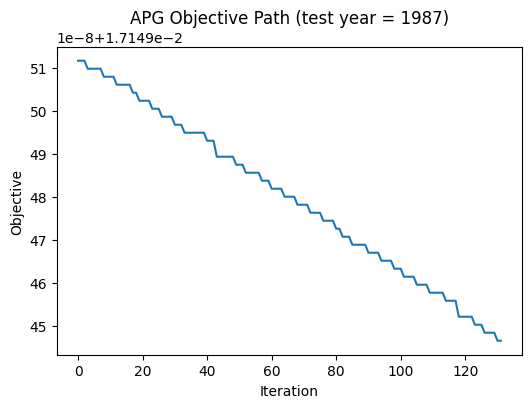

In [21]:
import matplotlib.pyplot as plt

obj_path = res_1987["solver_result"].obj_path

plt.figure(figsize=(6,4))
plt.plot(obj_path)
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.title(f"APG Objective Path (test year = {res_1987['test_year']})")
plt.show()

In [22]:
for feat, g in zip(FEATURE_NAMES, res_1987["train_design"].group_slices):
    print(feat, g, g.stop - g.start)

mom1m slice(0, 4, None) 4
mom6m slice(4, 8, None) 4
mom12m slice(8, 12, None) 4
baspread slice(12, 16, None) 4
